# SLAP-GRO — Phase 0: Data Audit & Reconciliation

This notebook provides an interactive inspection of all raw datasets, verifying schemas, delimiters, foreign keys, and known discrepancies between the literature setup and the supplied industrial dataset.

In [1]:
import sys
from pathlib import Path

# Ensure project root and src/ are in sys.path regardless of where the notebook kernel is launched
current_dir = Path.cwd().resolve()
project_root = current_dir.parent if current_dir.name == "notebooks" else current_dir

for path in [str(project_root), str(project_root / "src")]:
    if path not in sys.path:
        sys.path.insert(0, path)

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from slap_gro.config.loader import load_data_contract
from slap_gro.data import (
    load_products,
    load_storage_locations,
    load_navigation_points,
    load_customer_orders,
    load_picking_waves,
    load_storage_matrix,
)

# Load data contract
contract = load_data_contract()
print(f"Project Root: {project_root}")
print(f"Data Contract Version: {contract.get('version')}")

Project Root: C:\Users\Admin\Desktop\NCKH\SLAP GRO\slap-gro
Data Contract Version: 1.0.0


## 1. Load Summary Audit Table

In [2]:
# Resolve summary CSV path robustly from project root
summary_csv = project_root / "outputs" / "tables" / "data_audit_summary.csv"
if not summary_csv.exists():
    from scripts.audit_data import run_audit
    run_audit()

summary_df = pd.read_csv(summary_csv)
summary_df

,File,Size (MB),Delim,BOM,Rows,Cols,Nulls,Duplicate Rows
0,Product.csv,0.00,;,No,208,3,0,0
1,Storage_Location.csv,0.07,",",No,2292,5,0,0
2,Support_Points_Navigation.csv,0.00,;,No,44,2,0,0
3,Customer_Order.csv,9.02,;,Yes,122370,9,16,2559
4,Picking_Wave.csv,9.23,;,Yes,215192,6,0,102201
5,Random_Storage.csv,0.43,",",No,2292,19,0,0
6,Class_Based_Storage.csv,0.55,;,Yes,2341,20,0,0
7,Dedicated_Storage.csv,0.54,;,Yes,2340,20,0,0
8,Hybrid_Storage.csv,0.54,;,Yes,2340,20,0,0


## 2. Inspect Products (`Product.csv`)

In [3]:
prods = load_products()
print(f"Total unique products: {len(prods)}")
print("ABC Class Distribution:")
print(prods['ABCCOD'].value_counts())
prods.head()

Total unique products: 208
ABC Class Distribution:
ABCCOD
C    94
B    70
A    44
Name: count, dtype: int64


,Reference,ABCCOD,Sector
0,O9YFO8,A,PF
1,I1X92B,A,PF
2,HOUGRO,B,PF
3,D05ZS7,A,PF
4,XSFSKX,C,PF


## 3. Inspect Physical Storage Locations (`Storage_Location.csv`)

Total locations: 2292
Levels (z) distribution:
z
1    846
2    846
3    301
4    299
Name: count, dtype: int64


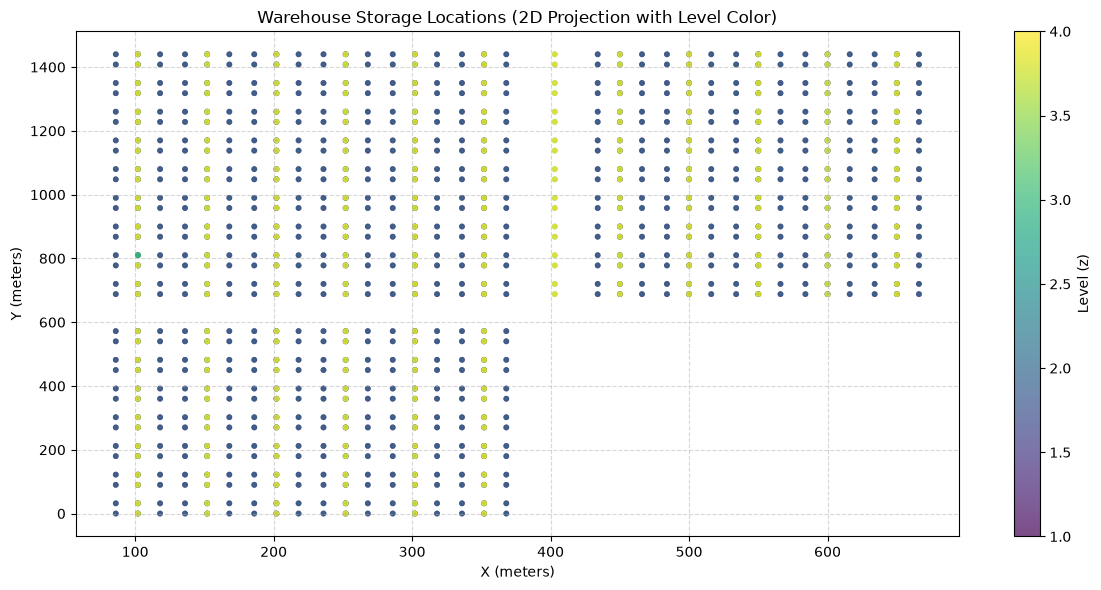

In [4]:
locs = load_storage_locations()
print(f"Total locations: {len(locs)}")
print("Levels (z) distribution:")
print(locs['z'].value_counts().sort_index())

# Visualize 2D scatter of locations
plt.figure(figsize=(12, 6))
scatter = plt.scatter(locs['x'], locs['y'], c=locs['z'], cmap='viridis', s=10, alpha=0.7)
plt.colorbar(scatter, label='Level (z)')
plt.title('Warehouse Storage Locations (2D Projection with Level Color)')
plt.xlabel('X (meters)')
plt.ylabel('Y (meters)')
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

## 4. Inspect Support Navigation Points (`Support_Points_Navigation.csv`)

In [5]:
nav = load_navigation_points()
print(f"Total navigation points: {len(nav)}")
nav.head(10)

Total navigation points: 44


,points_specified,labels
0,"(66.0, -29.0, 1.0)",LC-01
1,"(66.0, 61.0, 1.0)",LC-02
2,"(66.0, 151.0, 1.0)",LC-03
3,"(66.0, 241.0, 1.0)",LC-04
4,"(66.0, 331.0, 1.0)",LC-05
5,"(66.0, 421.0, 1.0)",LC-06
6,"(66.0, 511.0, 1.0)",LC-07
7,"(66.0, 631.0, 1.0)",LC-08
8,"(66.0, 751.0, 1.0)",LC-09
9,"(66.0, 841.0, 1.0)",LC-10


## 5. Storage Policies Comparison (Random, Class-Based, Dedicated, Hybrid)

In [6]:
rs = load_storage_matrix('random')
cb = load_storage_matrix('class_based')
ds = load_storage_matrix('dedicated')
hs = load_storage_matrix('hybrid')

print(f"Random Storage locations:     {len(rs)}")
print(f"Class-Based Storage locations:{len(cb)} (49 extra locations: aisles 25-26 + Q-26-20)")
print(f"Dedicated Storage locations:  {len(ds)} (48 extra locations: aisles 25-26)")
print(f"Hybrid Storage locations:     {len(hs)} (48 extra locations: aisles 25-26)")

Random Storage locations:     2292
Class-Based Storage locations:2341 (49 extra locations: aisles 25-26 + Q-26-20)
Dedicated Storage locations:  2340 (48 extra locations: aisles 25-26)
Hybrid Storage locations:     2340 (48 extra locations: aisles 25-26)
